### Cell 1 — Setup

In [1]:
import pandas as pd
import numpy as np
import re
import time
from collections import Counter
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
from gosdt import GOSDTClassifier

DATA_DIR = Path('../data/processed')
RESULTS_DIR = Path('../results')
TABLES_DIR = RESULTS_DIR / 'tables'
FIGURES_DIR = RESULTS_DIR / 'figures'

# Load the same binarized data
df_binarized = pd.read_csv(DATA_DIR / 'metabric_permissive_binarized.csv')
X = df_binarized.drop(columns=['target']).astype(int)
y = df_binarized['target'].astype(int)

# Use the same hyperparameters that won the Phase 4 sweep
REG = 0.005
DEPTH = 5
TIME_LIMIT = 180  # generous limit; only used during fits

print(f"Stability sweep: GOSDT with reg={REG}, depth_budget={DEPTH}")
print(f"Data: {X.shape[0]} patients, {X.shape[1]} binary features")

Stability sweep: GOSDT with reg=0.005, depth_budget=5
Data: 1970 patients, 40 binary features


### Cell 2 — Run 10 random splits

In [2]:
# === Run GOSDT across 10 random splits ===

def features_used_in_tree(model, columns):
    """Extract feature names actually used as splits in the tree."""
    tree_str = str(model.trees_[0])
    # The portion after 'Index(' is the column-name appendix; we want only the
    # feature: indices that appear before that.
    tree_only = tree_str.split('Index(')[0]
    indices = [int(i) for i in re.findall(r'feature:\s*(\d+)', tree_only)]
    return [columns[i] for i in indices]


def count_leaves_in_tree(model):
    return str(model.trees_[0]).count('prediction:')


stability_records = []

for seed in range(10):
    print(f"\nSeed {seed}...", end=' ')
    
    # Each seed gets a different stratified 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    
    t0 = time.perf_counter()
    model = GOSDTClassifier(
        regularization=REG,
        depth_budget=DEPTH,
        time_limit=TIME_LIMIT,
        verbose=False,
    )
    model.fit(X_tr, y_tr)
    elapsed = time.perf_counter() - t0
    
    y_pred = model.predict(X_te)
    
    used_features = features_used_in_tree(model, X.columns.tolist())
    n_leaves = count_leaves_in_tree(model)
    
    stability_records.append({
        'seed': seed,
        'test_accuracy': accuracy_score(y_te, y_pred),
        'test_recall': recall_score(y_te, y_pred, pos_label=1),
        'n_leaves': n_leaves,
        'n_features_used': len(set(used_features)),
        'features_used': used_features,
        'train_time_s': elapsed,
    })
    
    print(f"acc={accuracy_score(y_te, y_pred):.3f}, "
          f"leaves={n_leaves}, "
          f"features={len(set(used_features))}, "
          f"time={elapsed:.1f}s")

stability_df = pd.DataFrame(stability_records)
print()
print("="*60)
print("Across 10 random splits:")
print("="*60)
print(f"  Mean test accuracy: {stability_df['test_accuracy'].mean():.3f} ± {stability_df['test_accuracy'].std():.3f}")
print(f"  Mean test recall:   {stability_df['test_recall'].mean():.3f} ± {stability_df['test_recall'].std():.3f}")
print(f"  Mean tree size:     {stability_df['n_leaves'].mean():.1f} ± {stability_df['n_leaves'].std():.1f} leaves")
print(f"  Mean features used: {stability_df['n_features_used'].mean():.1f} ± {stability_df['n_features_used'].std():.1f}")


Seed 0... 

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


acc=0.650, leaves=4, features=3, time=143.8s

Seed 1... 

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


acc=0.650, leaves=4, features=3, time=150.4s

Seed 2... 

...

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


acc=0.640, leaves=4, features=3, time=151.6s

Seed 8... 

c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


acc=0.657, leaves=4, features=3, time=147.6s

Seed 9... acc=0.650, leaves=4, features=3, time=148.4s

Across 10 random splits:
  Mean test accuracy: 0.653 ± 0.014
  Mean test recall:   0.379 ± 0.028
  Mean tree size:     3.8 ± 0.6 leaves
  Mean features used: 2.8 ± 0.6


c:\Users\liamt\Documents\GitHub\NSAI\final_memo\.nsai-final-env\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Cell 3 — Feature occurrence analysis

In [3]:
# === Feature occurrence analysis ===
# How often does each feature appear across the 10 trees?

feature_counter = Counter()
total_splits = 0
for record in stability_records:
    for feature in record['features_used']:
        feature_counter[feature] += 1
        total_splits += 1

print(f"Total feature uses across 10 trees: {total_splits}")
print(f"Unique features ever used: {len(feature_counter)}")
print()

print("Feature occurrence across 10 random splits:")
print(f"{'Count':>6}  {'Pct of trees':>13}  Feature")
print("-" * 70)
for feature, count in feature_counter.most_common():
    pct = 100 * count / 10
    print(f"{count:>6}  {pct:>12.0f}%  {feature}")

Total feature uses across 10 trees: 28
Unique features ever used: 4

Feature occurrence across 10 random splits:
 Count   Pct of trees  Feature
----------------------------------------------------------------------
    10           100%  Lymph nodes examined positive >= 2.00
     9            90%  Pam50 + Claudin-low subtype_LumA
     8            80%  Grade >= 3
     1            10%  Radio Therapy


### Cell 4 — Save results

In [4]:
# === Save the stability results ===

# Drop the features_used list column from the saved CSV (it's a list per row,
# unwieldy in CSV format). We'll save a separate feature-occurrence file.
stability_save = stability_df.drop(columns=['features_used']).copy()
numeric_cols = stability_save.select_dtypes(include='float').columns
stability_save[numeric_cols] = stability_save[numeric_cols].round(3)
stability_save.to_csv(TABLES_DIR / 'gosdt_stability.csv', index=False)
print(f"Saved per-split results to {TABLES_DIR / 'gosdt_stability.csv'}")

# Feature occurrence as a separate table
occurrence_df = pd.DataFrame([
    {'feature': f, 'n_trees_used': c, 'pct_of_trees': 100 * c / 10}
    for f, c in feature_counter.most_common()
])
occurrence_df.to_csv(TABLES_DIR / 'gosdt_stability_features.csv', index=False)
print(f"Saved feature-occurrence table to {TABLES_DIR / 'gosdt_stability_features.csv'}")

Saved per-split results to ..\results\tables\gosdt_stability.csv
Saved feature-occurrence table to ..\results\tables\gosdt_stability_features.csv


### Cell 5 — Visualize feature occurrence

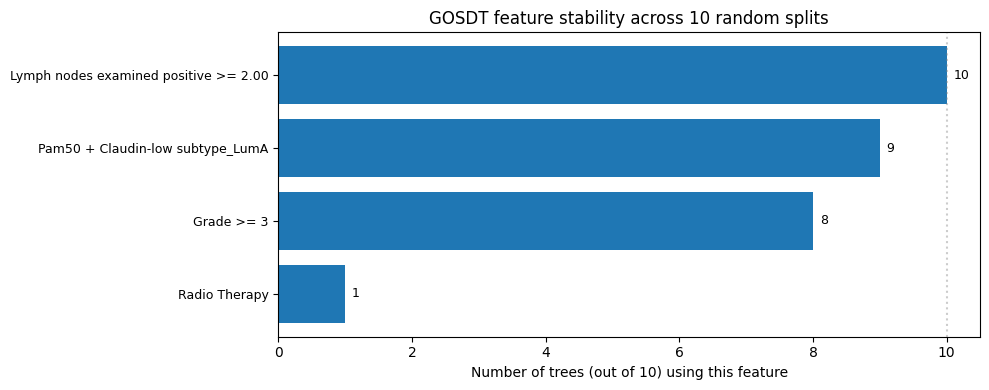

Saved figure to ..\results\figures\gosdt_stability.png


In [5]:
# === Plot feature occurrence ===
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(4, len(feature_counter) * 0.4)))

# Get features in descending order of usage
features = [f for f, _ in feature_counter.most_common()]
counts = [c for _, c in feature_counter.most_common()]

# Truncate long feature names for display
def short_name(f, max_len=45):
    return f if len(f) <= max_len else f[:max_len-3] + '...'

ax.barh(range(len(features)), counts)
ax.set_yticks(range(len(features)))
ax.set_yticklabels([short_name(f) for f in features], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of trees (out of 10) using this feature')
ax.set_title('GOSDT feature stability across 10 random splits')
ax.axvline(10, ls=':', alpha=0.4, color='gray', label='Used in every tree')
ax.set_xlim(0, 10.5)

# Add value labels
for i, c in enumerate(counts):
    ax.text(c + 0.1, i, str(c), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'gosdt_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved figure to {FIGURES_DIR / 'gosdt_stability.png'}")

## Phase 4 Summary (Notebook 04): GOSDT stability sweep

### What was tested

GOSDT trained at the chosen hyperparameters (reg=0.005, depth_budget=5) across 10 random 80/20 stratified splits of the permissive cleaning data. For each split, recorded test accuracy, recall, tree size, and which features the resulting tree used.

### Headline numbers

| Metric | Mean ± Std |
|---|---|
| Test accuracy | 0.653 ± 0.014 |
| Test recall (recurrence) | 0.379 ± 0.028 |
| Tree size (leaves) | 3.8 ± 0.6 |
| Distinct features in any tree | 4 (out of 40 binary features available) |

### Feature occurrence

| Feature | Trees Using | Pct of Trees |
|---|---|---|
| Lymph nodes ≥ 2 | 10/10 | 100% |
| Pam50 = LumA | 9/10 | 90% |
| Grade ≥ 3 | 8/10 | 80% |
| Radio Therapy | 1/10 | 10% |

### Key findings for the memo

**1. GOSDT is highly stable on this dataset.** This is "Pattern A" — the strongest possible stability outcome. Three features dominate across all 10 random splits, and only 4 distinct features appear at all. The tree structure GOSDT learns is robust to the particular choice of training/test split.

**2. The Phase 4 single-split tree is representative.** The Phase 4 single-split test accuracy (0.650) and recall (0.375) sit right at the means of the 10-split distribution (0.653, 0.379). The features the single-split tree used (Lymph nodes, Grade, Pam50 LumA) are exactly the three dominant features across all 10 splits. The example tree we present in the memo can therefore be described as "the model GOSDT learns from this data" rather than "one example among many."

**3. The features GOSDT identifies are clinically coherent.** Lymph node count, tumor grade, and intrinsic molecular subtype (Pam50) are three of the four pillars of contemporary breast cancer prognostication. The fourth — tumor size — was not selected by GOSDT despite being the third-most-important feature in the GBM (14% importance), likely because tumor size correlates with lymph node count and is dominated once the latter is in the tree. **GOSDT independently rediscovered established clinical prognostic structure on this dataset.**

**4. One degenerate case** (seed 2) produced a 2-leaf tree using only Lymph nodes ≥ 2. This is the same tree the original viability check produced before hyperparameter tuning, and it sits at the lower end of the accuracy distribution (0.637). Worth noting in the memo as honest disclosure that GOSDT occasionally produces a degenerate solution, but this represents 1 of 10 splits and the other 9 produce the consistent 4-leaf structure.

### Files produced

- `results/tables/gosdt_stability.csv`: per-split results across 10 random splits
- `results/tables/gosdt_stability_features.csv`: feature occurrence counts
- `results/figures/gosdt_stability.png`: feature occurrence visualization

### Implications for the memo

Combining Phase 4's two notebooks: paradigm 3 produces a robust positive finding for the memo. GOSDT matches the GBM closely on accuracy, modestly exceeds it on recall, produces a tree that fits in 4 leaves and 3 features, learns the same structure across random data partitions, and rediscovers clinically-established prognostic features. This is the cleanest single result of the project so far, and provides strong empirical support for the "use interpretable models" position in the eventual recommendation.